# 07 — Report Figures

Generates all tables and plots required for the written report.
Each figure function is independent — runs from saved output files
and can be re-run individually after any upstream change.

| Fig | Output | Requires |
|-----|--------|---------|
| 1a | `model_performance_primary.csv` + `fig1_model_performance.png` | `model_comparison_by_threshold.csv` |
| 1b | `fig1b_rmse_heatmap_all_thresholds.png` | same |
| 2  | `fig2_feature_importance_consensus.png` | `shap_feature_importance_comparison.csv` |
| 3  | `fig3_trajectory_{country}.png` × 5 | `poverty_predictions_ssp.csv` |
| 4  | `fig4_regional_trends.png` | `poverty_predictions_ssp.csv` |
| 5  | `fig5_approach_divergence.png` | `approach_comparison.csv` |
| 6  | `fig6_learning_curve.png` | `X_train.csv`, `y_train.csv`, model pkl |
| 7  | `fig7_residual_analysis.png` | `X_test.csv`, `y_test.csv`, model pkl |


## 0. Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from report_figures import (
    generate_all_figures,
    fig1_model_performance_table,
    fig2_feature_importance_consensus,
    fig3_prediction_trajectories,
    fig4_regional_trends,
    fig5_approach_divergence,
    fig6_learning_curve,
    fig7_residual_analysis,
    REPORT_DIR,
    MODEL_DISPLAY,
    THRESHOLD_DISPLAY,
)
from config import DATA_FINAL_DIR, OUTPUTS_DIR

REPORT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Report output dir: {REPORT_DIR}")

# Check what upstream outputs are available
to_check = [
    OUTPUTS_DIR / "model_comparison_by_threshold.csv",
    OUTPUTS_DIR / "shap_feature_importance_comparison.csv",
    OUTPUTS_DIR / "approach_comparison.csv",
    DATA_FINAL_DIR / "poverty_predictions_ssp.csv",
    DATA_FINAL_DIR / "X_train.csv",
    DATA_FINAL_DIR / "X_test.csv",
]
print("\nUpstream file status:")
for p in to_check:
    exists = p.exists()
    size   = f"{p.stat().st_size:>10,} bytes" if exists else "NOT FOUND"
    print(f"  {'✓' if exists else '✗'}  {p.name:<50}  {size}")

Report output dir: /Users/noahg/Downloads/SSP_v2/src/outputs/report

Upstream file status:
  ✓  model_comparison_by_threshold.csv                        7,123 bytes
  ✓  shap_feature_importance_comparison.csv                   2,427 bytes
  ✓  approach_comparison.csv                             17,814,797 bytes
  ✓  poverty_predictions_ssp.csv                          1,367,854 bytes
  ✓  X_train.csv                                            822,138 bytes
  ✓  X_test.csv                                             288,169 bytes


## 1. Model performance table (Fig 1)

In [2]:
tables = fig1_model_performance_table(OUTPUTS_DIR)

if tables:
    print("Primary table ($3/day):")
    display(tables["primary"])
    print("\nAll thresholds (RMSE):")
    display(tables["wide"])

  Saved: model_performance_primary.csv
  Saved: model_performance_all_thresholds.csv
  Saved: fig1_model_performance.png
  Saved: fig1b_rmse_heatmap_all_thresholds.png
Primary table ($3/day):


,Model,RMSE,MAE,R²,MAPE (%),Time (s),Train RMSE
0,Random Forest,2.219288e+12,5.249867e+11,-0.0593,100.0,0.3,1.304474e+12
1,XGBoost CPU,2.219288e+12,5.249867e+11,-0.0593,100.0,0.3,1.304474e+12
2,XGBoost GPU,2.219288e+12,5.249867e+11,-0.0593,100.0,0.2,1.304474e+12
3,Ridge,2.219288e+12,5.249867e+11,-0.0593,100.0,0.0,1.304474e+12
4,GAM,2.219288e+12,5.249867e+11,-0.0593,100.0,0.1,1.304474e+12
5,MLP,2.219288e+12,5.249867e+11,-0.0593,100.0,0.1,1.304474e+12



All thresholds (RMSE):


RMSE,$3,$4.20,$8.30,$10,Mean RMSE
model_name,,,,,
XGBoost CPU,2.219288e+12,2.219288e+12,6.6750,7.2832,1.109644e+12
XGBoost GPU,2.219288e+12,2.219288e+12,6.6750,7.2832,1.109644e+12
Random Forest,2.219288e+12,2.219288e+12,8.3113,8.7081,1.109644e+12
MLP,2.219288e+12,2.219288e+12,8.1222,8.4552,1.109644e+12
GAM,2.219288e+12,2.219288e+12,8.6277,9.0230,1.109644e+12
Ridge,2.219288e+12,2.219288e+12,10.2780,11.0261,1.109644e+12


### 1b. Figure inline

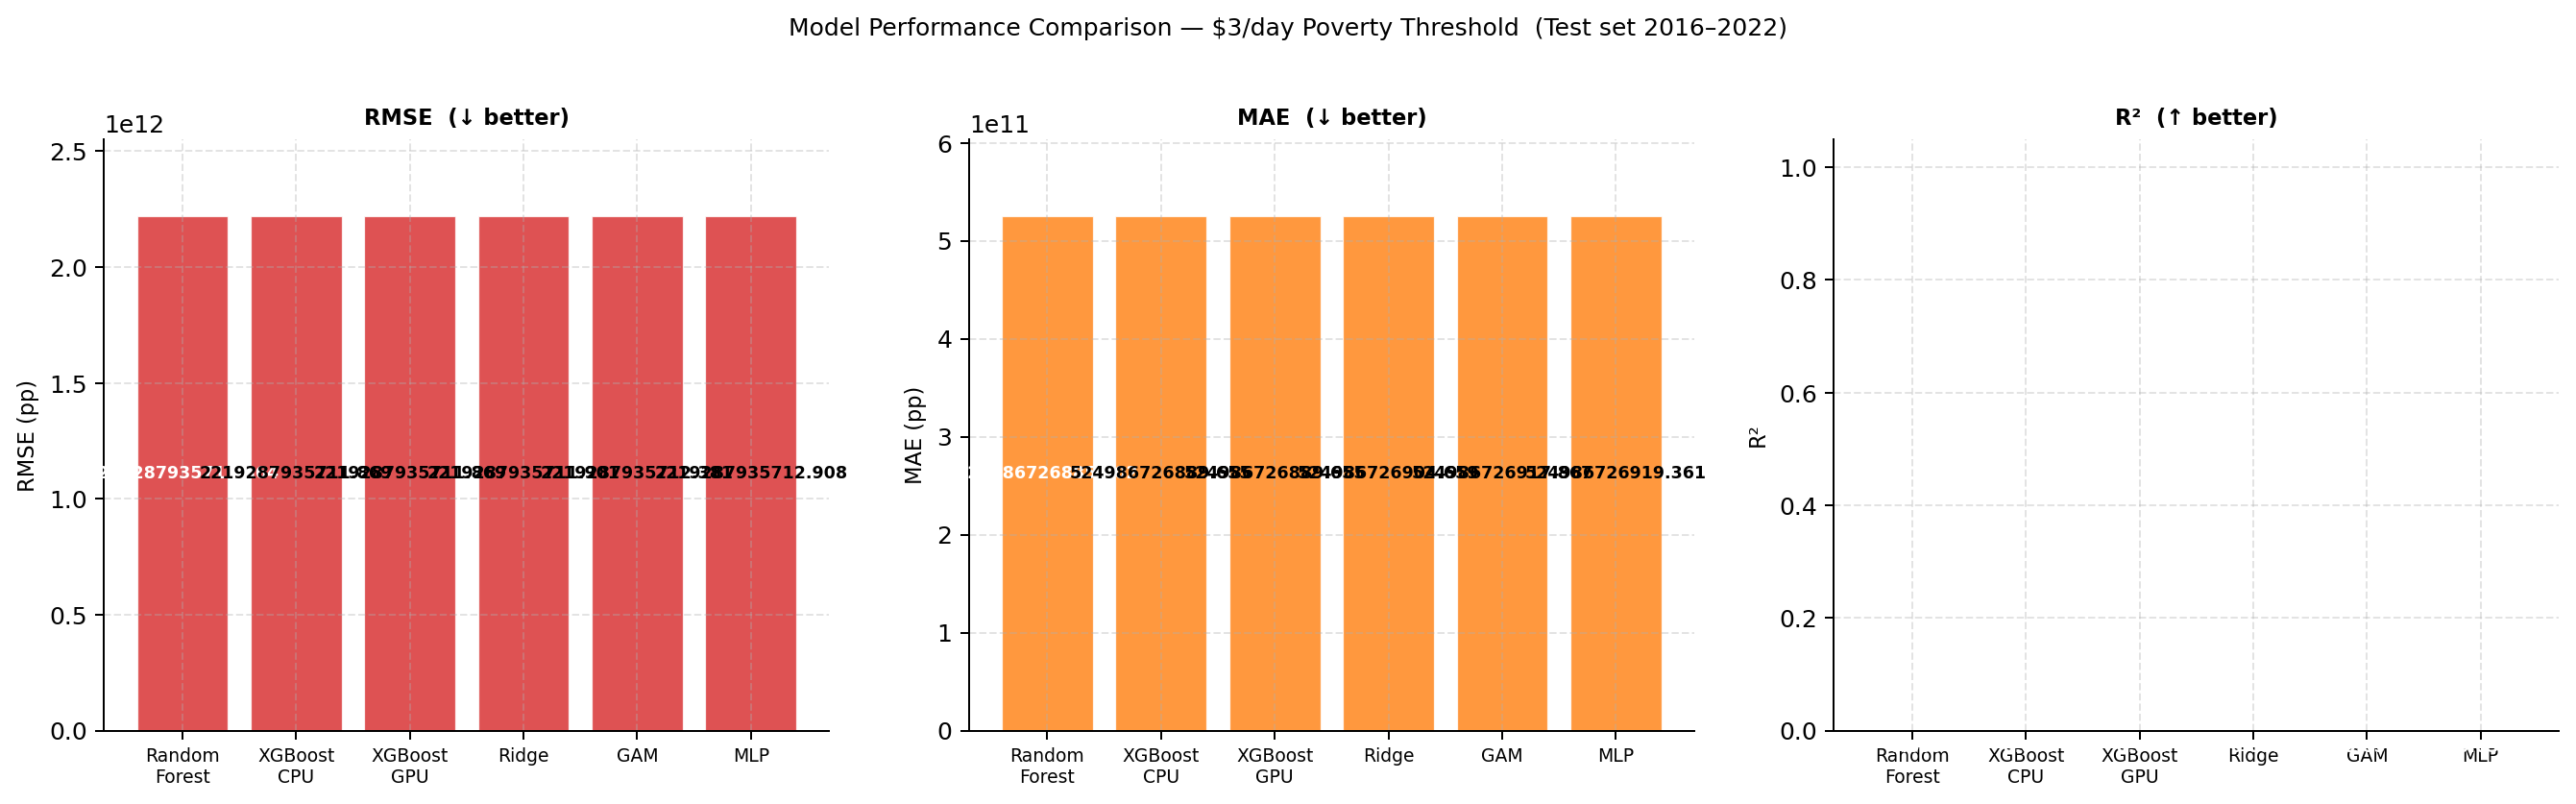

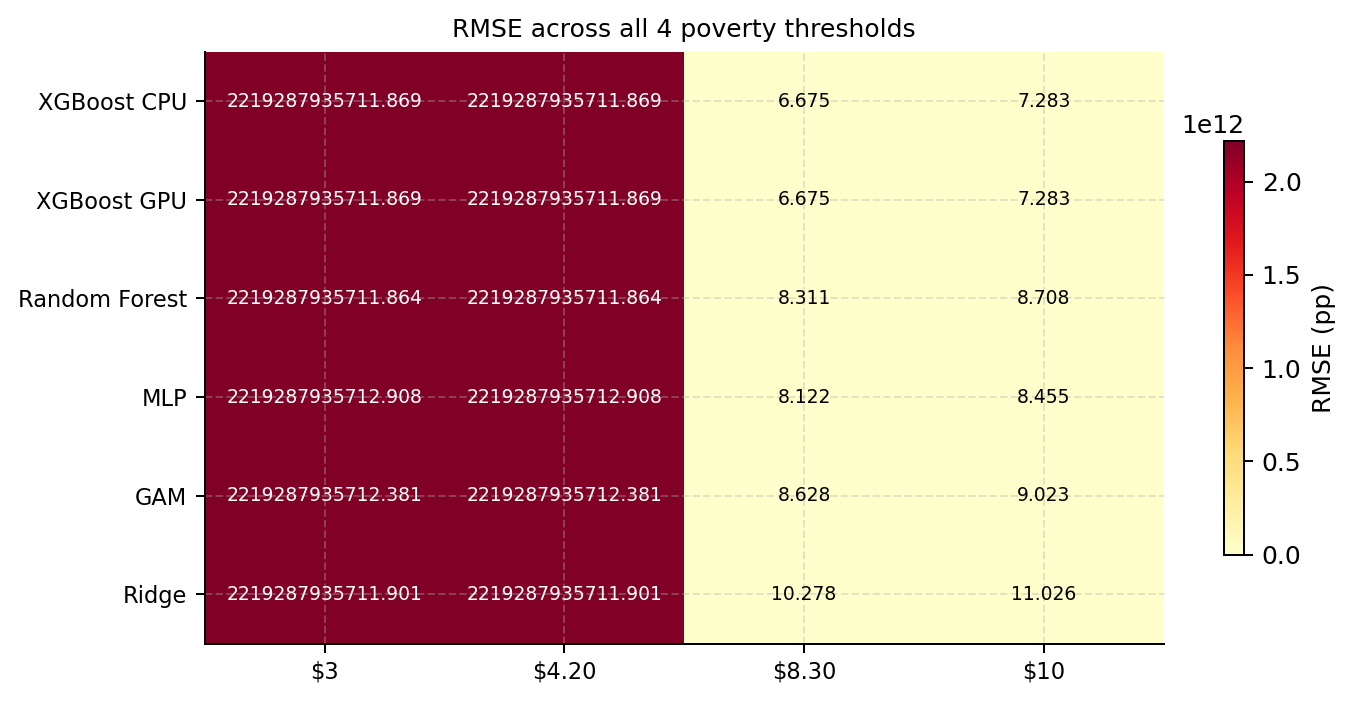

In [3]:
from IPython.display import Image, display
for fname in ["fig1_model_performance.png", "fig1b_rmse_heatmap_all_thresholds.png"]:
    p = REPORT_DIR / fname
    if p.exists():
        display(Image(str(p)))

## 2. Feature importance consensus (Fig 2)

In [4]:
imp = fig2_feature_importance_consensus(OUTPUTS_DIR)
if imp is not None:
    model_cols = [m for m in ["xgboost_cpu","xgboost_gpu","lightgbm",
                               "random_forest","gam","ridge","mlp"]
                  if m in imp.columns]
    display(imp[["feature_label"] + model_cols + ["mean_across_models","rank_mean"]].round(4))

  Saved: fig2_feature_importance_consensus.png


,feature_label,xgboost_cpu,xgboost_gpu,lightgbm,random_forest,gam,ridge,mlp,mean_across_models,rank_mean
feature,,,,,,,,,,
log_population,log(Population),4.429820e+11,4.429820e+11,4.374324e+11,4.688323e+11,3.924461e+11,3.112528e+11,17.3501,3.565611e+11,1
log_gdp_pc,log(GDP per capita),1.970436e+11,1.970436e+11,2.502447e+11,1.603593e+11,1.702337e+11,3.070919e+11,15.1315,1.831452e+11,2
hdi,Human Development Index,9.816898e+10,9.816898e+10,6.176681e+10,9.506279e+10,3.122069e+11,8.268377e+10,16.4528,1.068655e+11,3
region_NAC,Region: North America,2.847596e+10,2.847596e+10,4.694925e+10,3.793951e+10,1.159812e+11,7.326807e+10,2.7617,4.729856e+10,4
gini_coefficient,Gini Coefficient,2.516939e+10,2.516939e+10,9.763684e+09,9.628911e+09,1.877636e+11,5.574532e+10,13.0046,4.474861e+10,5
control_of_corruption,Control of Corruption,1.998461e+10,1.998461e+10,1.567920e+10,2.661628e+09,1.847052e+11,9.173659e+09,18.4457,3.602698e+10,6
employment_agriculture,Employment in Agriculture (%),2.893007e+10,2.893007e+10,9.275486e+09,5.166954e+10,1.082463e+11,1.803604e+10,13.2826,3.501250e+10,7
region_EAP,Region: East Asia & Pacific,1.473130e+10,1.473130e+10,1.367374e+10,1.975439e+10,9.425356e+08,8.544521e+10,12.7576,2.132550e+10,8
region_LAC,Region: Latin America & Caribbean,2.571599e+09,2.571599e+09,9.736963e+07,1.941194e+08,7.352229e+10,4.561002e+10,11.0986,1.779529e+10,9


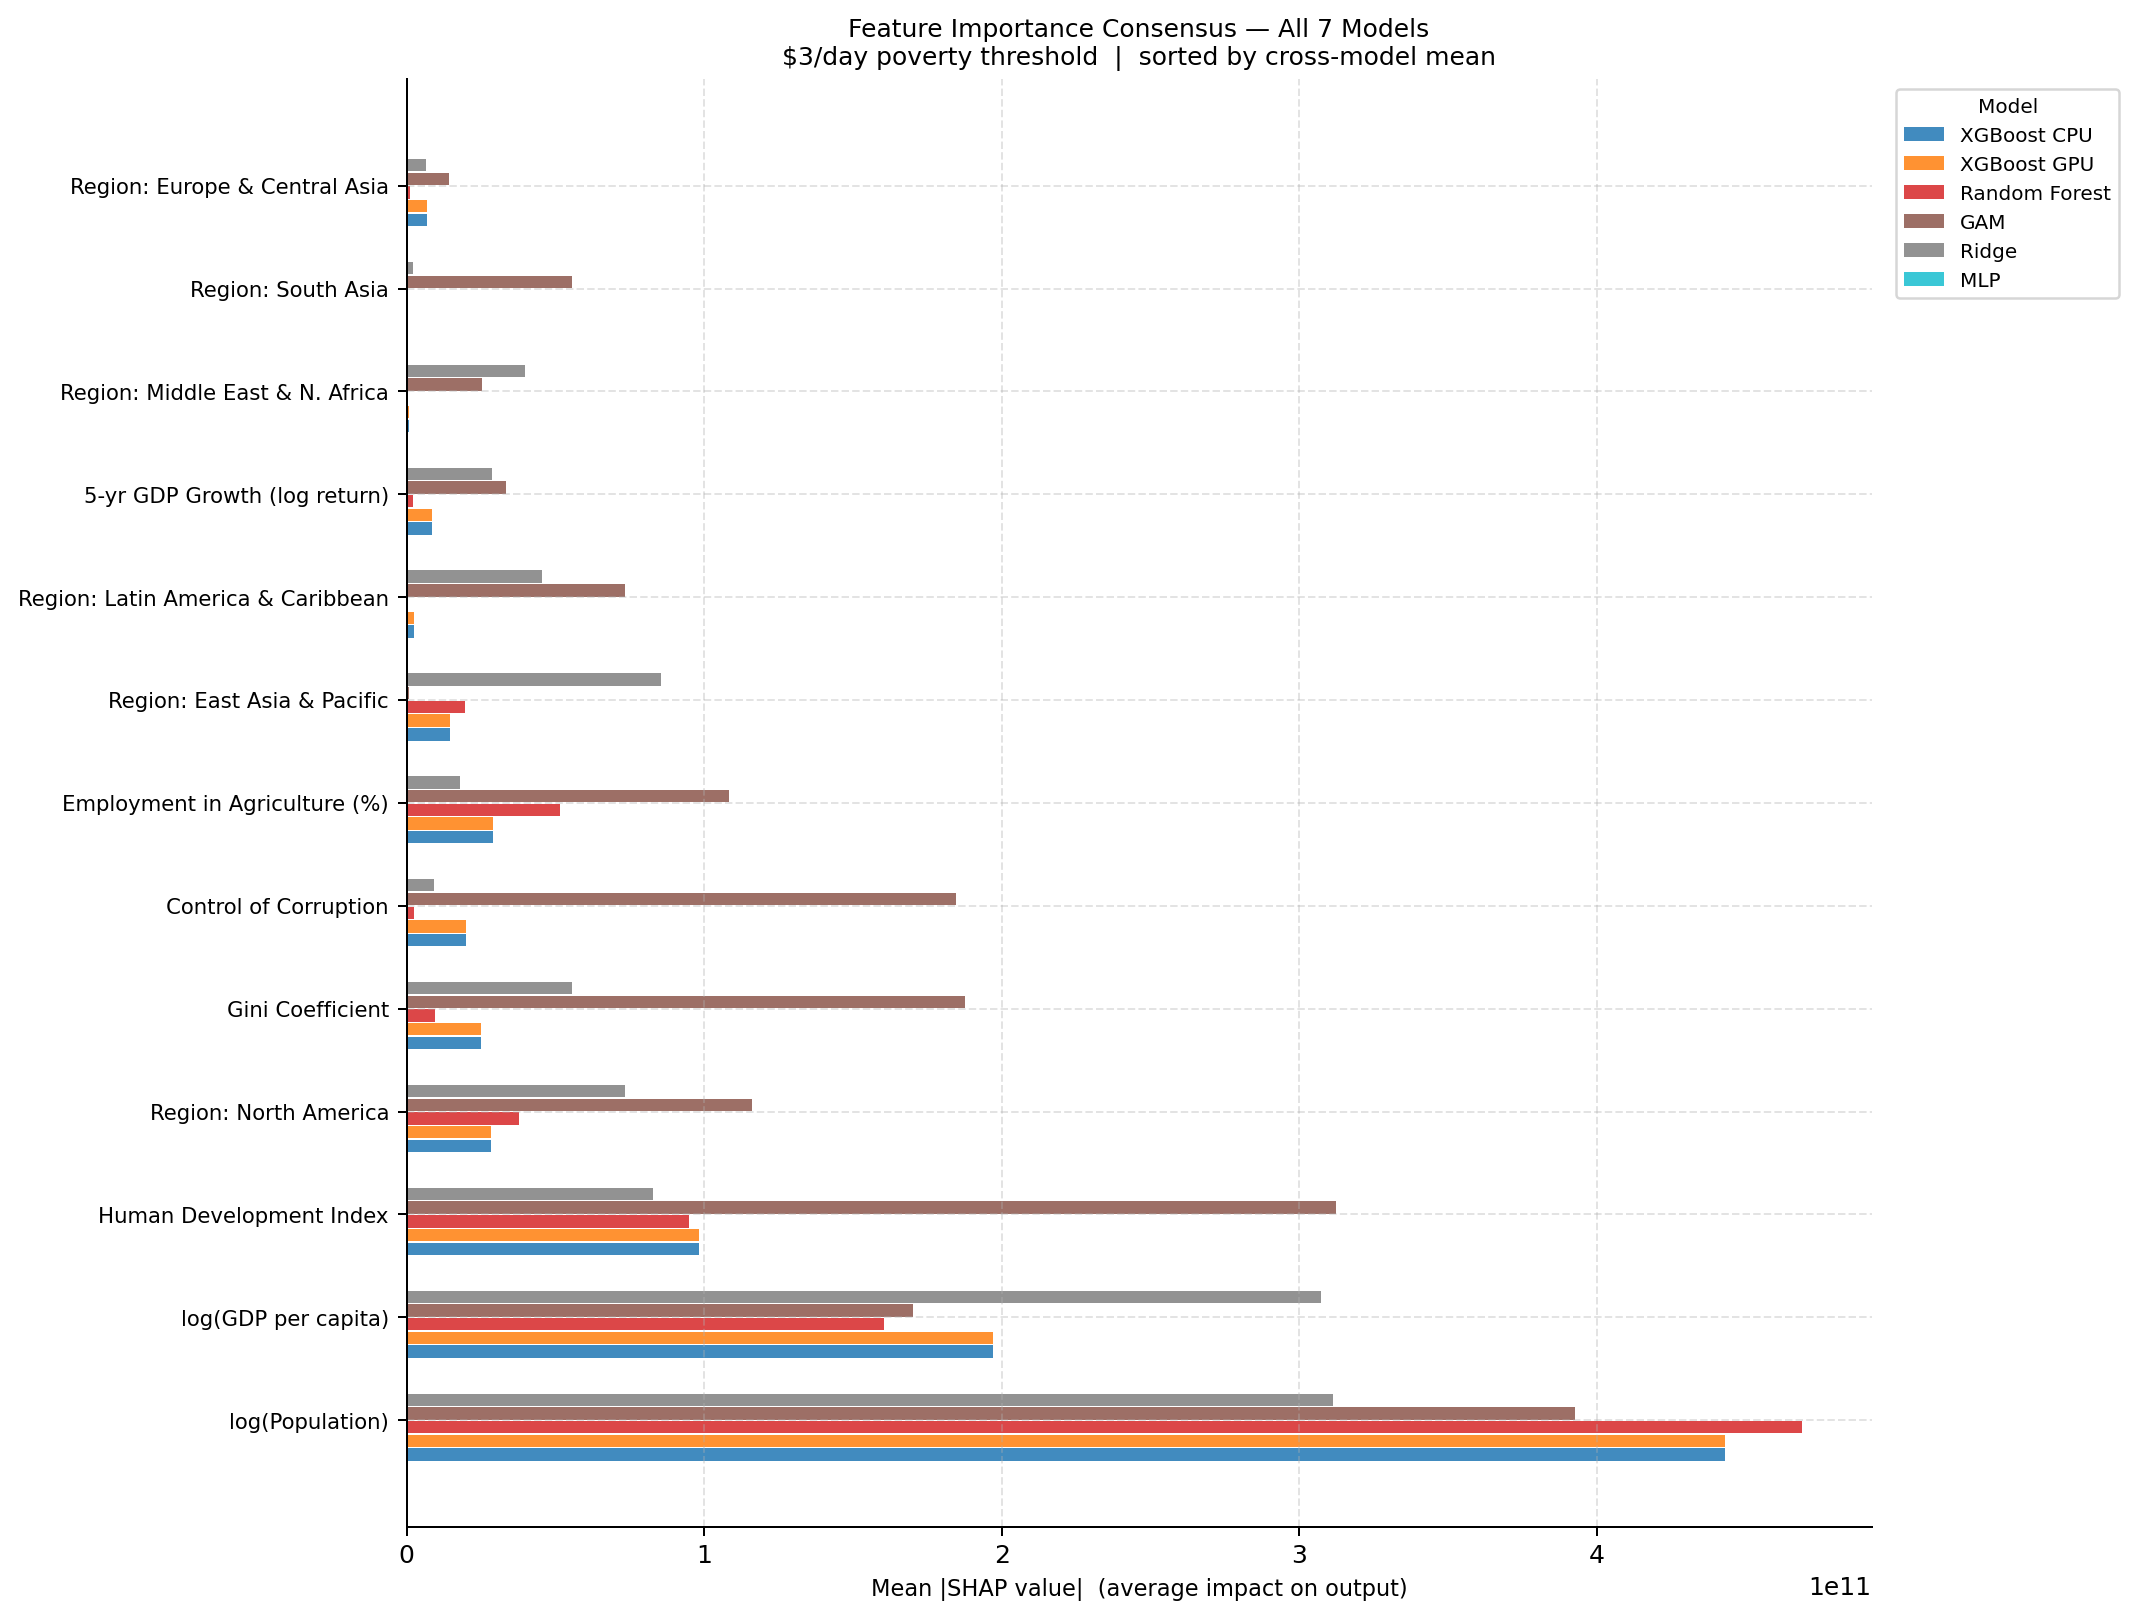

In [5]:
p = REPORT_DIR / "fig2_feature_importance_consensus.png"
if p.exists():
    display(Image(str(p)))

## 3. Country trajectory plots (Fig 3)

  Saved: fig3_trajectory_Nigeria.png
  Saved: fig3_trajectory_India.png
  Saved: fig3_trajectory_Brazil.png
  Saved: fig3_trajectory_Germany.png
  Saved: fig3_trajectory_United_States.png

Nigeria


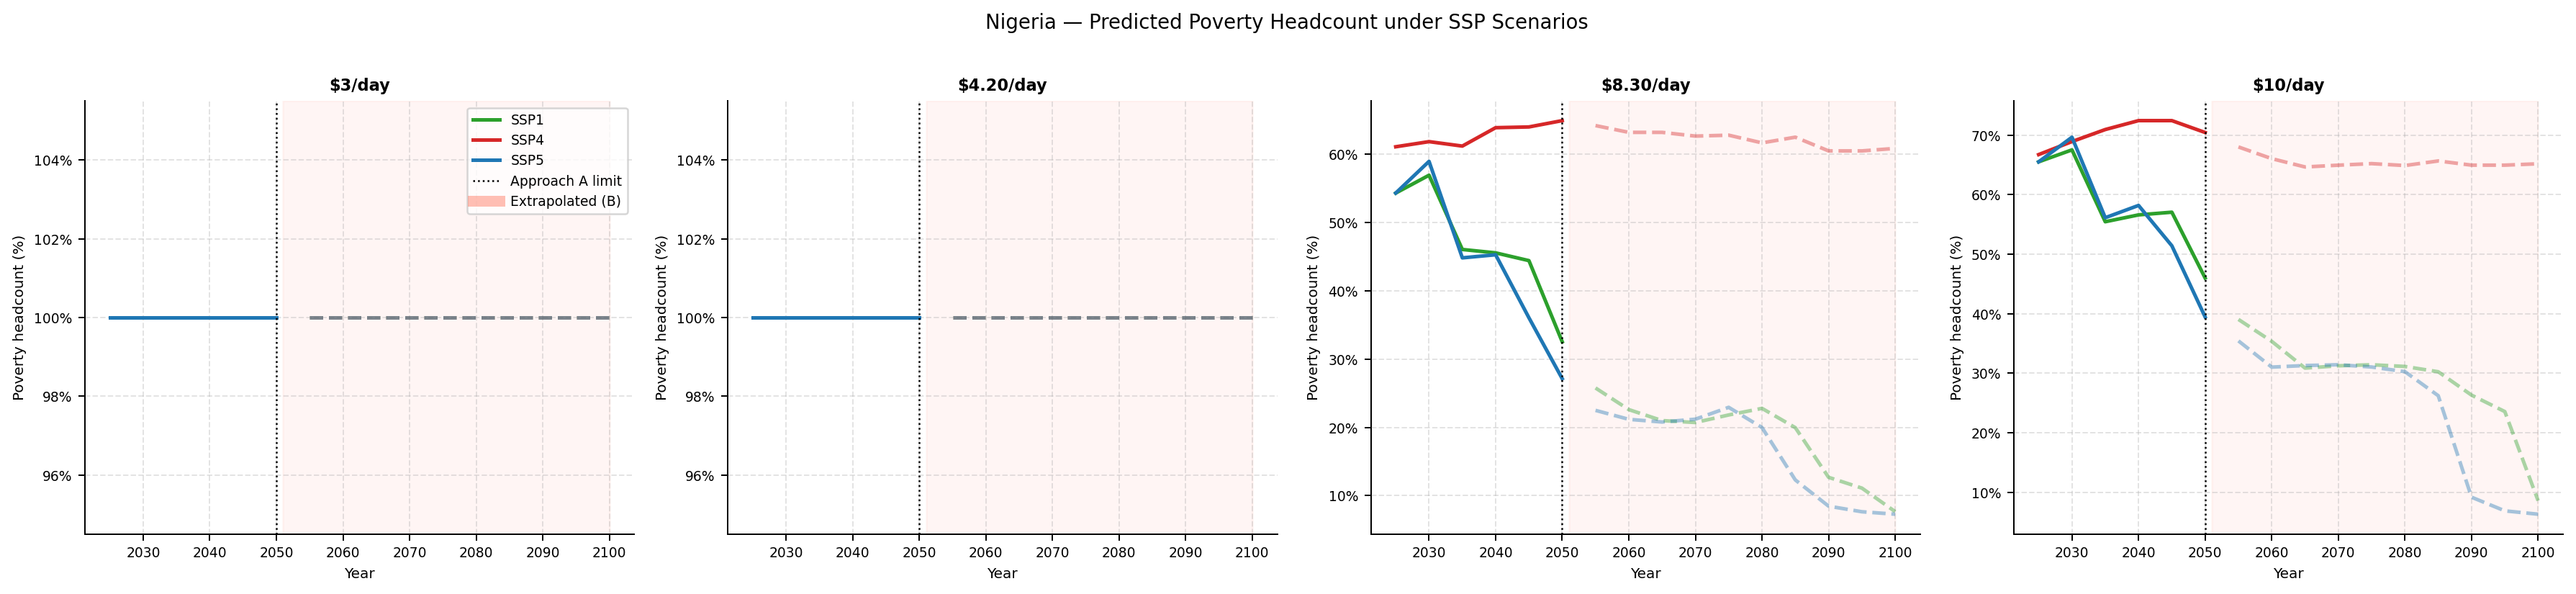


India


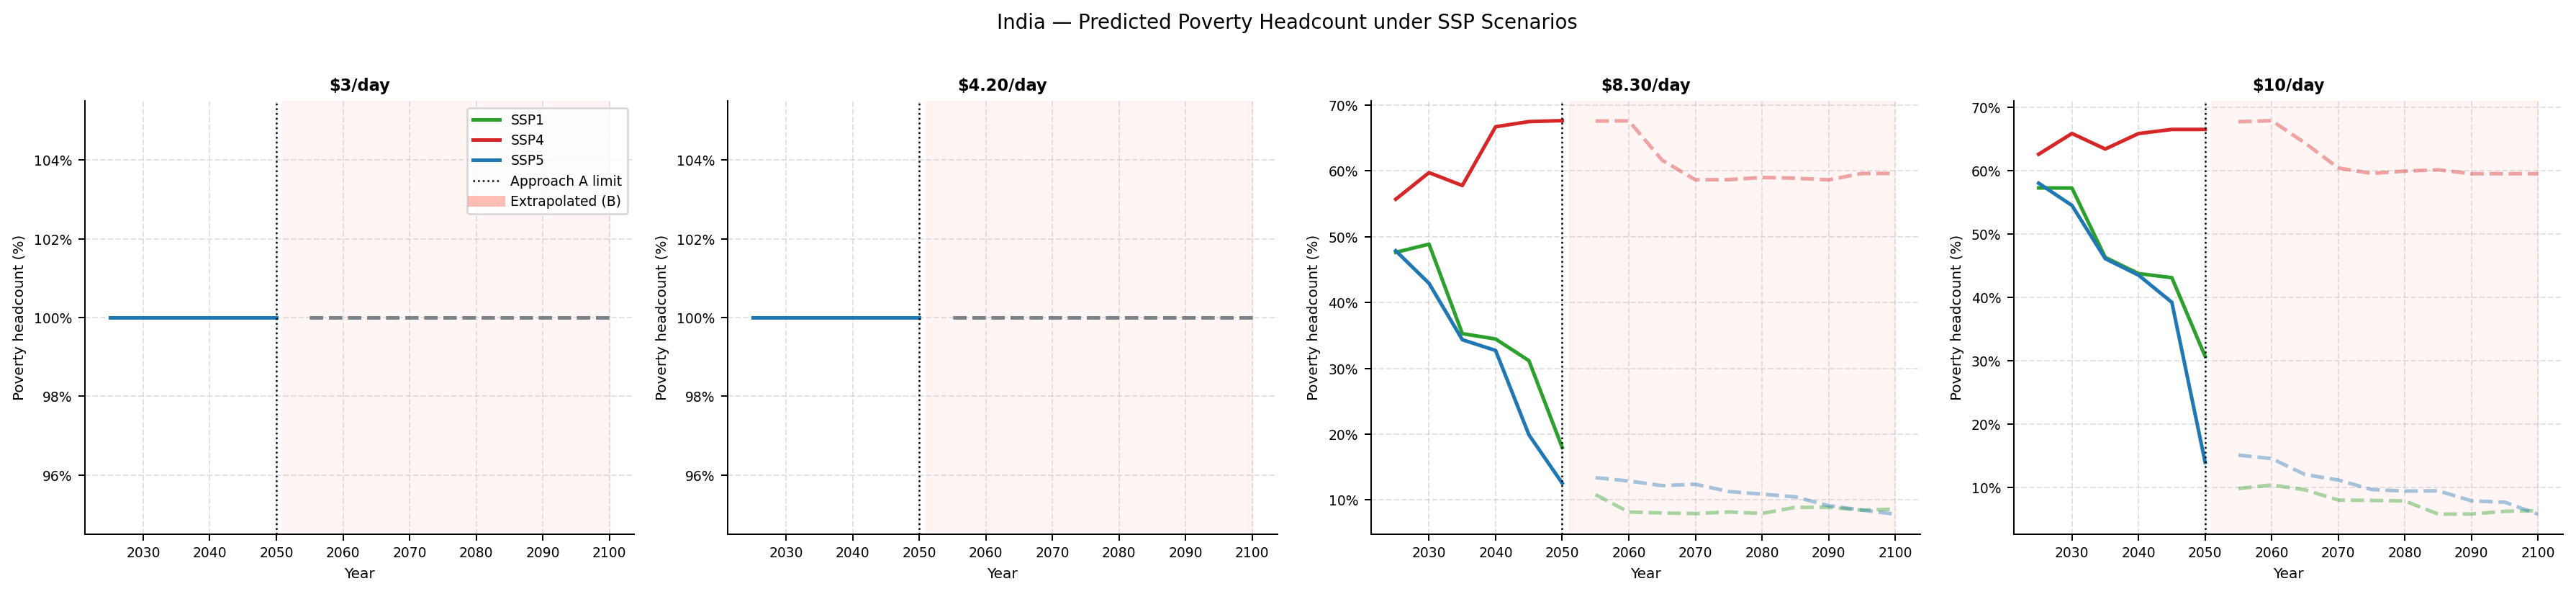


Brazil


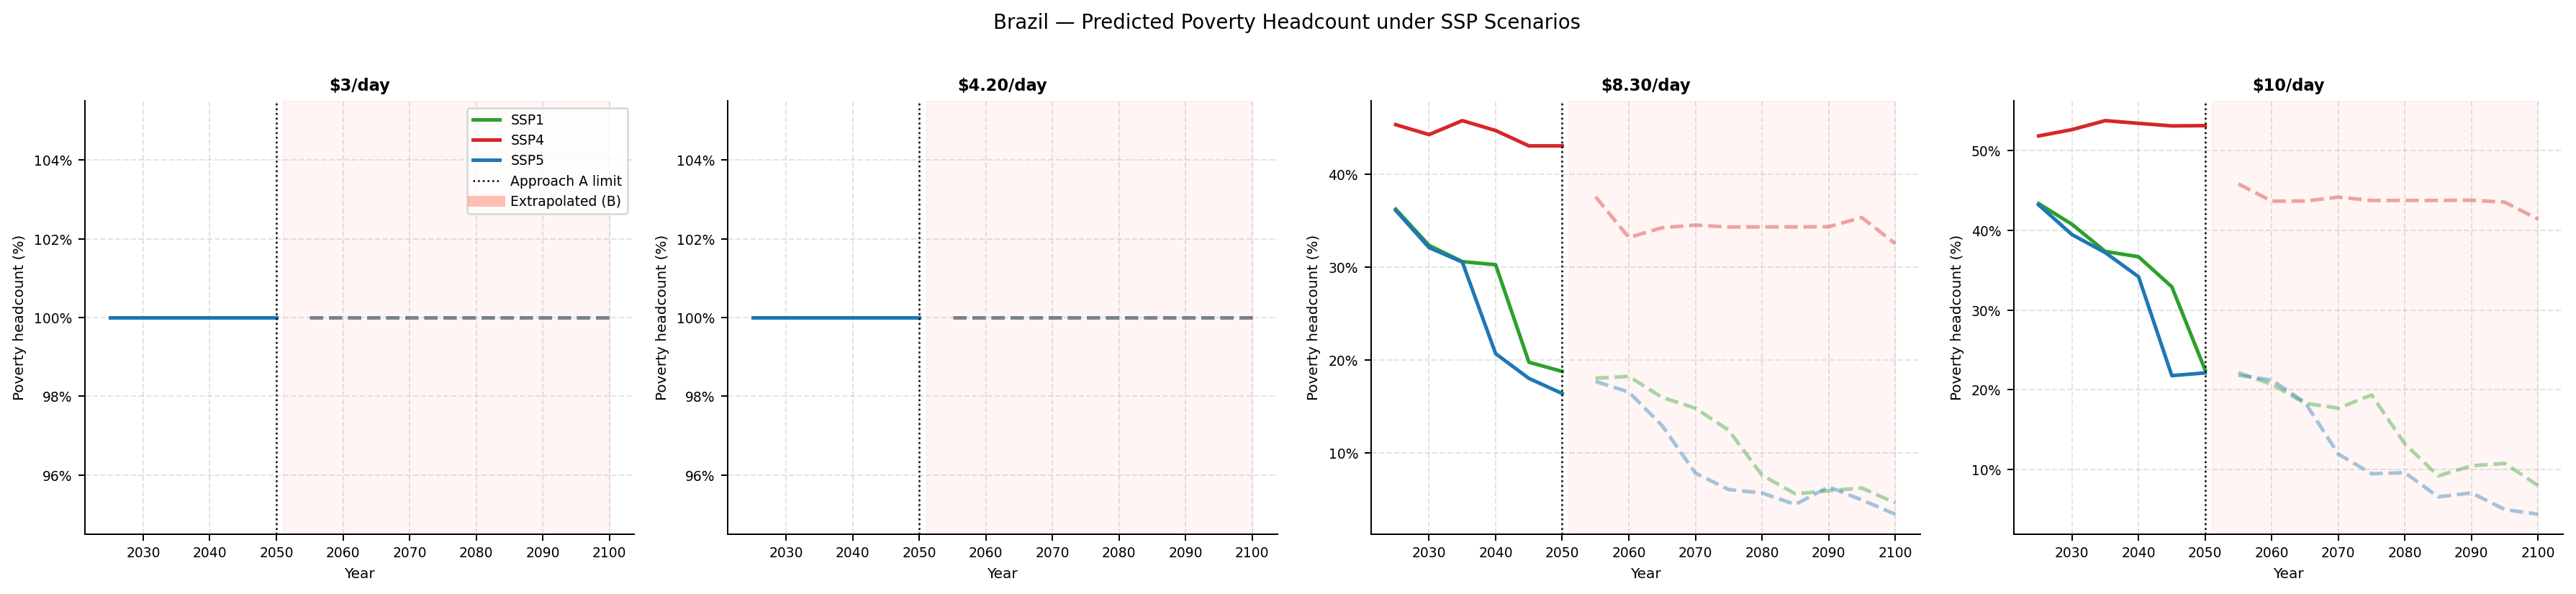


Germany


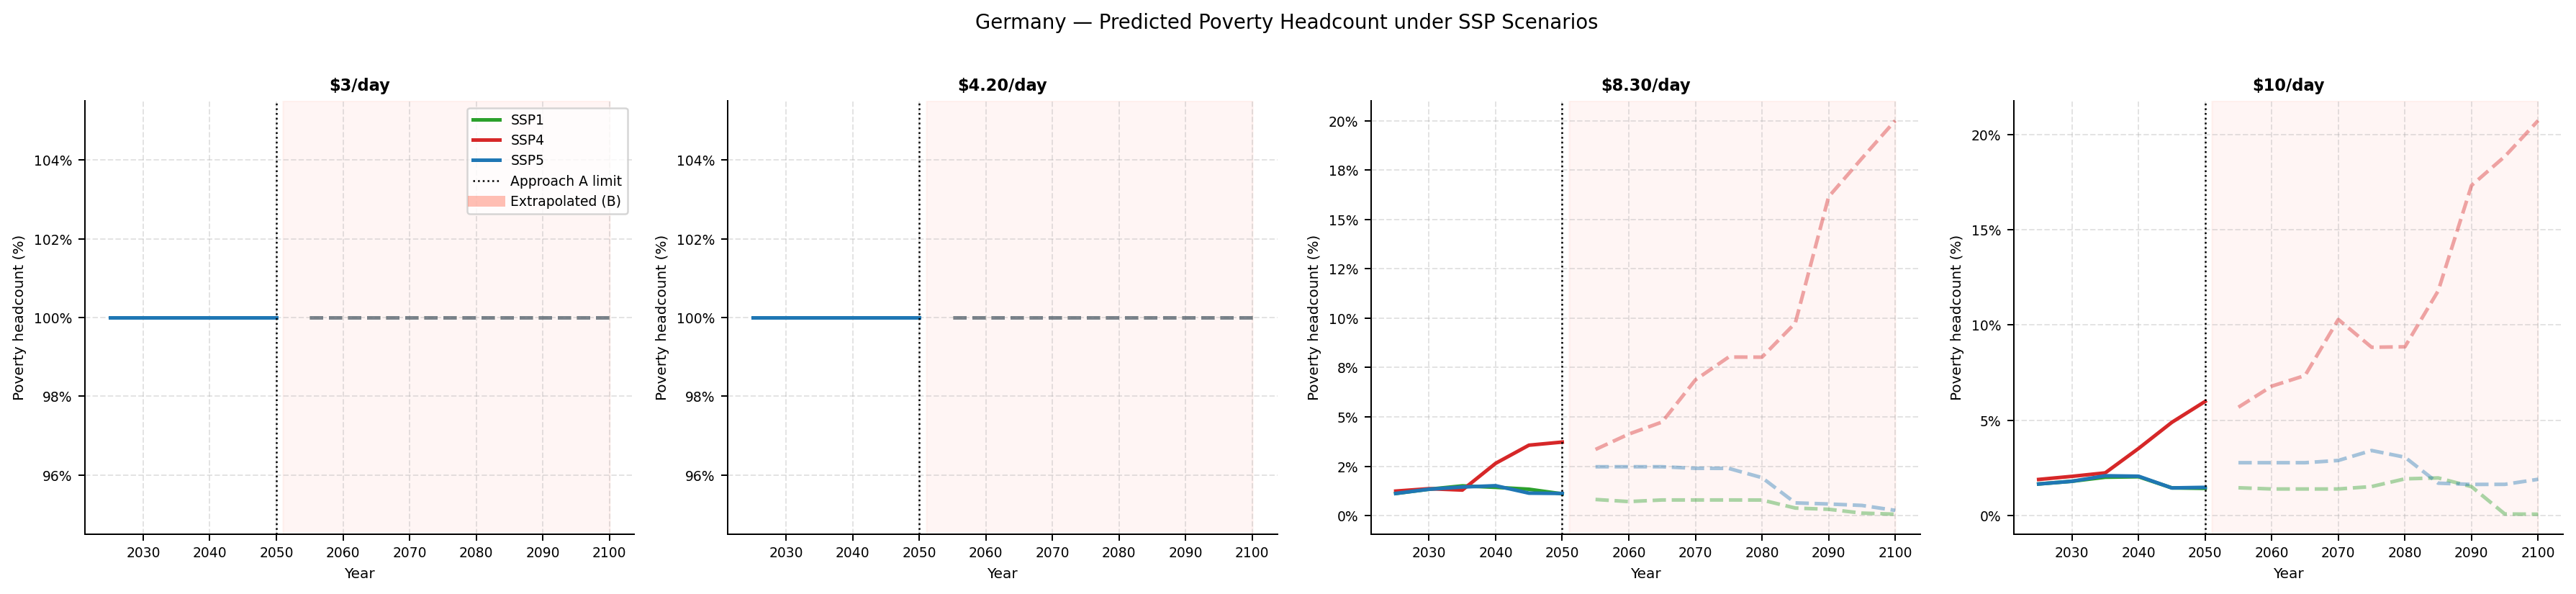


United States


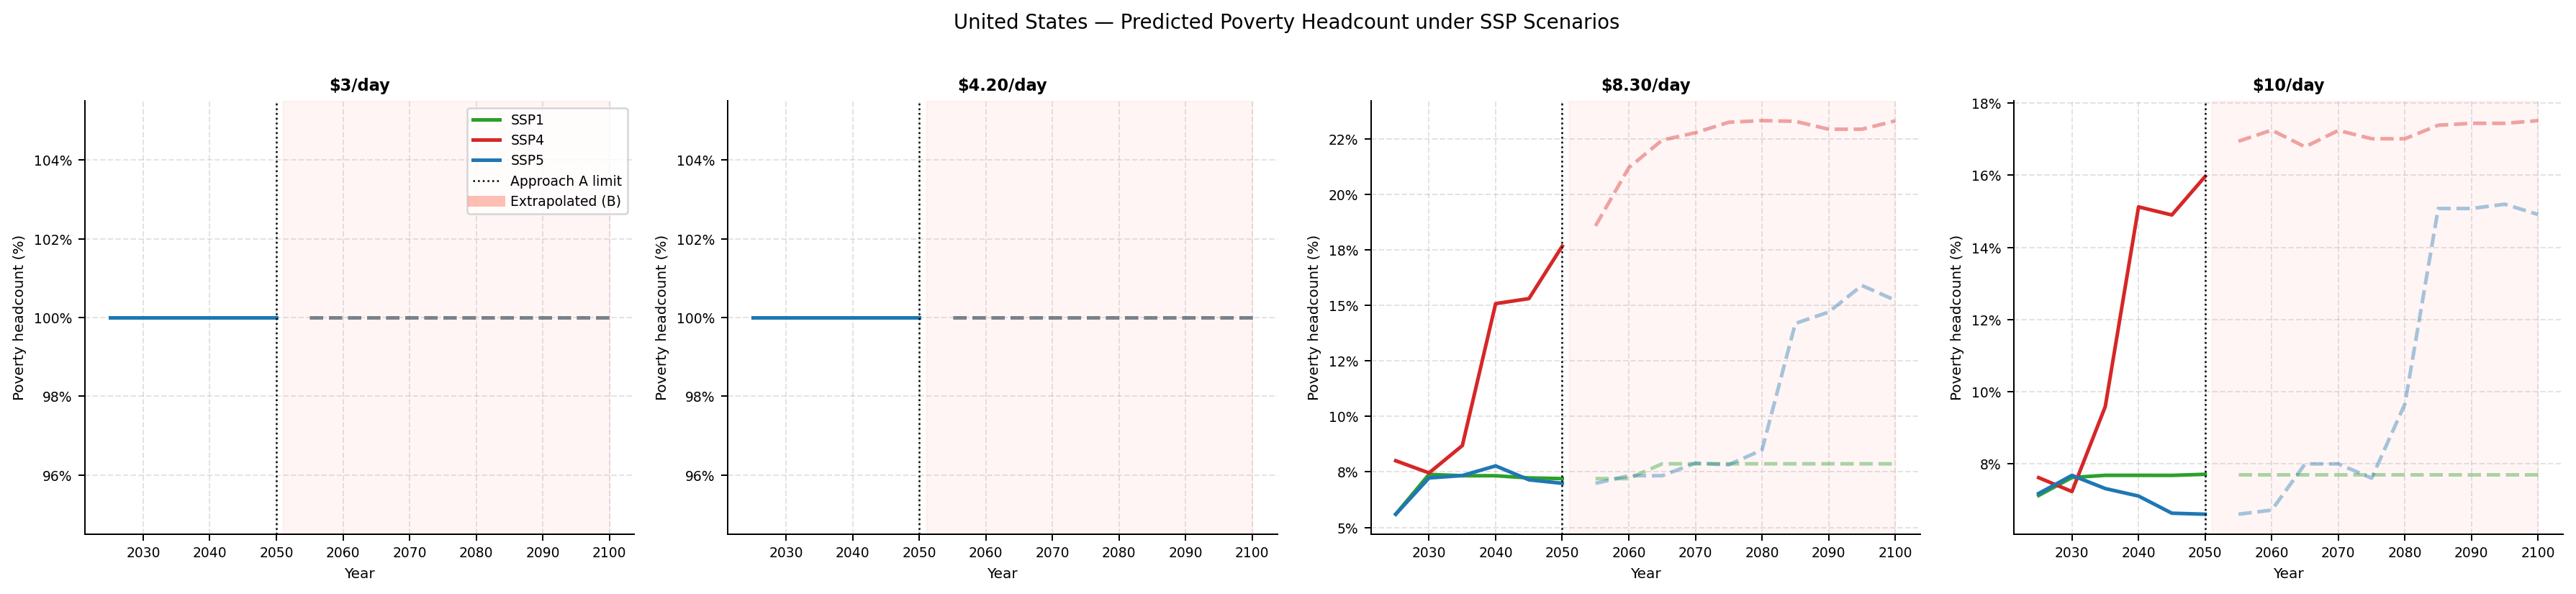

In [6]:
COUNTRIES = ["Nigeria", "India", "Brazil", "Germany", "United States"]
fig3_prediction_trajectories(DATA_FINAL_DIR, countries=COUNTRIES)

for country in COUNTRIES:
    safe = country.replace(" ", "_").replace(".", "")
    p = REPORT_DIR / f"fig3_trajectory_{safe}.png"
    if p.exists():
        print(f"\n{country}")
        display(Image(str(p)))

## 4. Regional trends (Fig 4)

  Saved: fig4_regional_trends.png


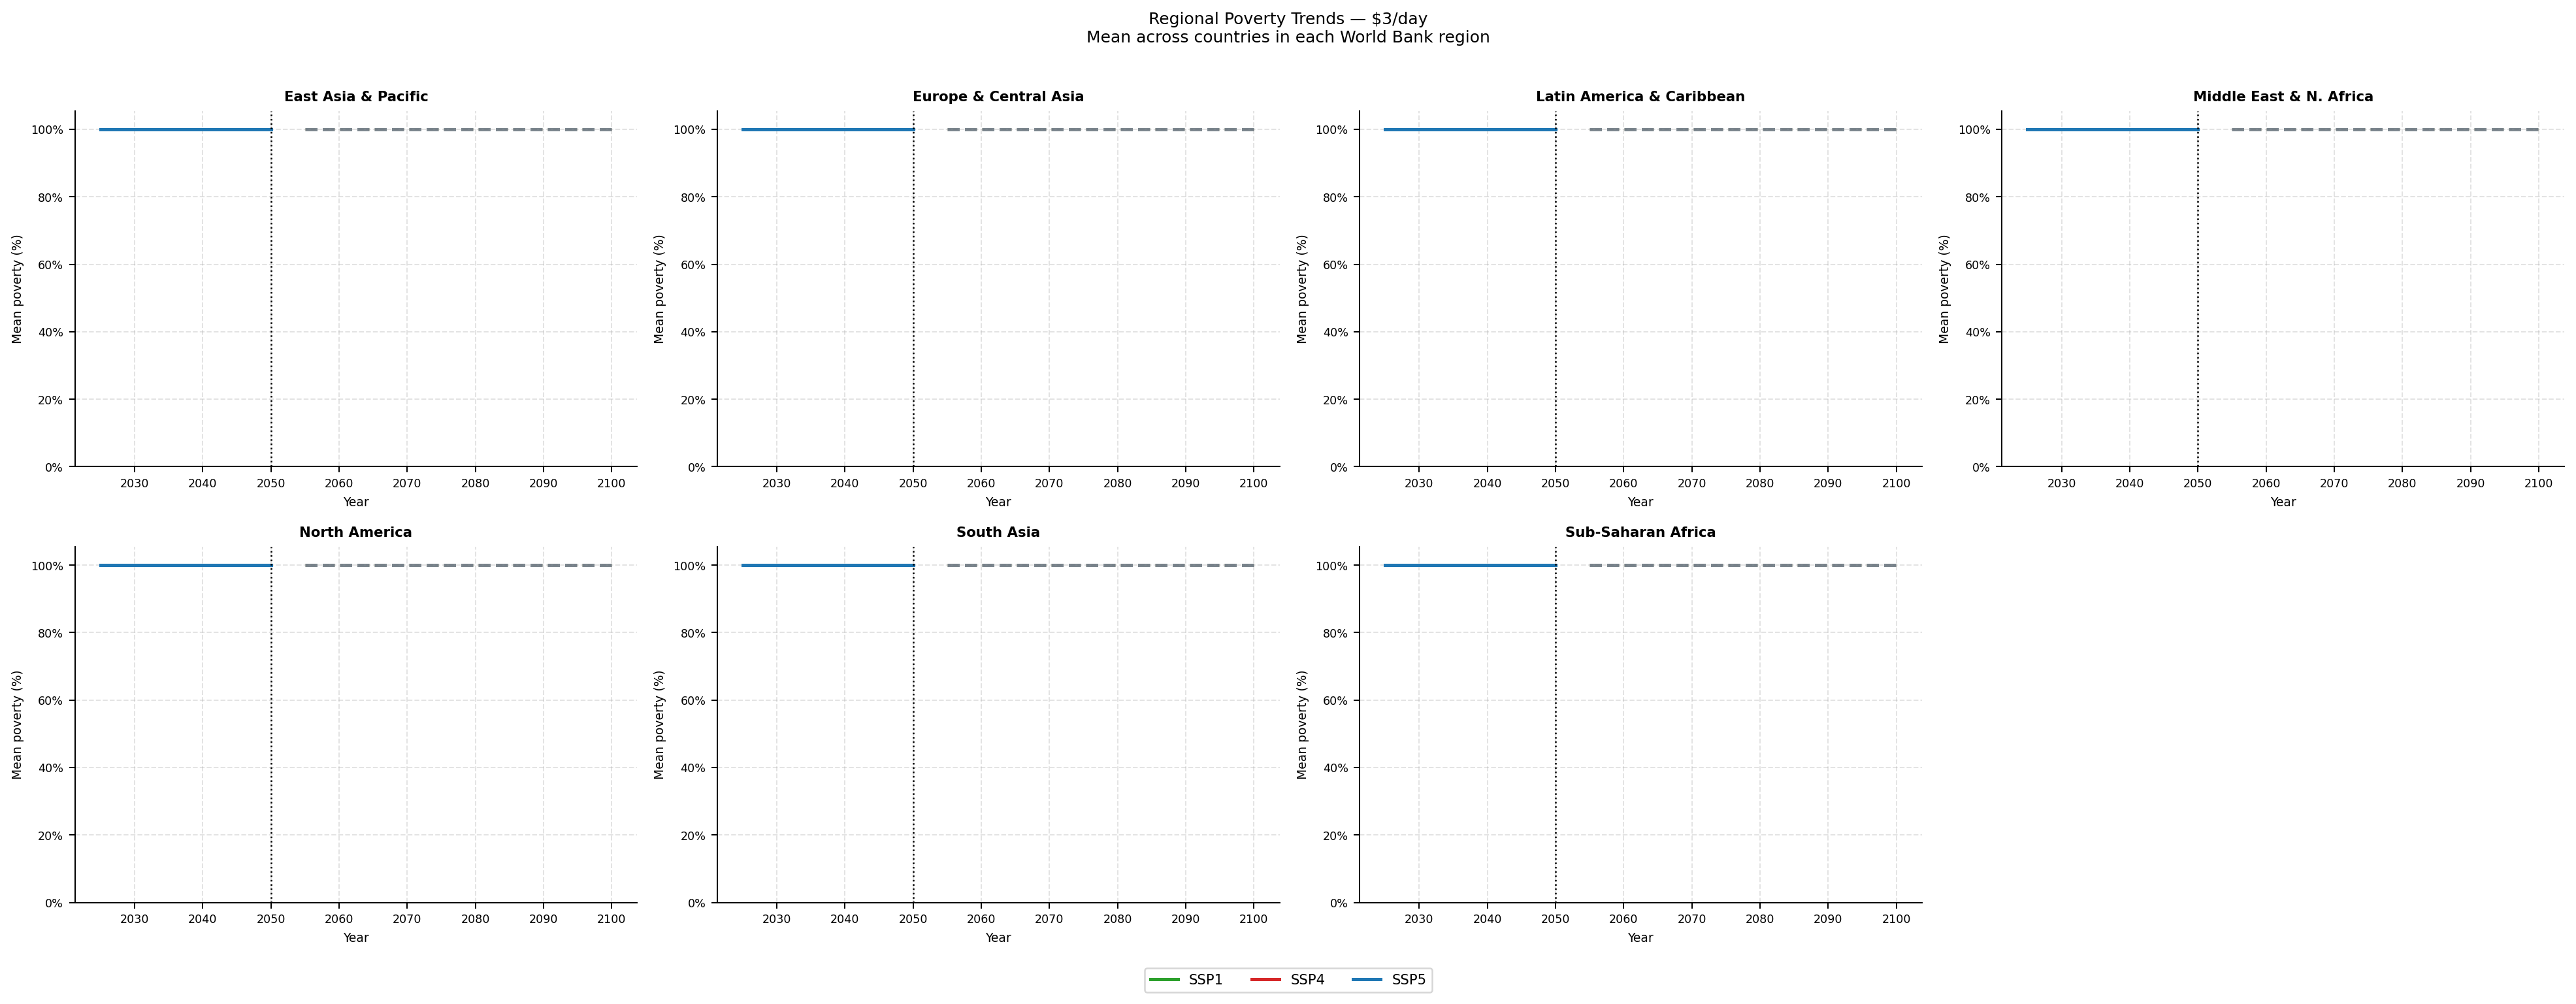

In [7]:
agg = fig4_regional_trends(DATA_FINAL_DIR)
p = REPORT_DIR / "fig4_regional_trends.png"
if p.exists():
    display(Image(str(p)))

### 4a. Regional summary table

In [8]:
if agg is not None:
    summary = (
        agg[agg["year"].isin([2030, 2050, 2075, 2100])]
        .pivot_table(index=["region","scenario"], columns="year",
                     values="predicted_poverty")
        .round(2)
    )
    display(summary)

year              2030   2050   2075   2100
region scenario                            
EAP    SSP1      100.0  100.0  100.0  100.0
       SSP4      100.0  100.0  100.0  100.0
       SSP5      100.0  100.0  100.0  100.0
ECA    SSP1      100.0  100.0  100.0  100.0
       SSP4      100.0  100.0  100.0  100.0
       SSP5      100.0  100.0  100.0  100.0
LAC    SSP1      100.0  100.0  100.0  100.0
       SSP4      100.0  100.0  100.0  100.0
       SSP5      100.0  100.0  100.0  100.0
MENA   SSP1      100.0  100.0  100.0  100.0
       SSP4      100.0  100.0  100.0  100.0
       SSP5      100.0  100.0  100.0  100.0
NAC    SSP1      100.0  100.0  100.0  100.0
       SSP4      100.0  100.0  100.0  100.0
       SSP5      100.0  100.0  100.0  100.0
Other  SSP1      100.0  100.0  100.0  100.0
       SSP4      100.0  100.0  100.0  100.0
       SSP5      100.0  100.0  100.0  100.0
SAS    SSP1      100.0  100.0  100.0  100.0
       SSP4      100.0  100.0  100.0  100.0
       SSP5      100.0  100.0  100.0  100.0
SSA    SSP1      100.0  100.0  100.0  100.0
       SSP4      100.0  100.0  100.0  100.0
       SSP5      100.0  100.0  100.0  100.0

## 5. Approach A vs B divergence (Fig 5)

  Saved: fig5_approach_divergence.png


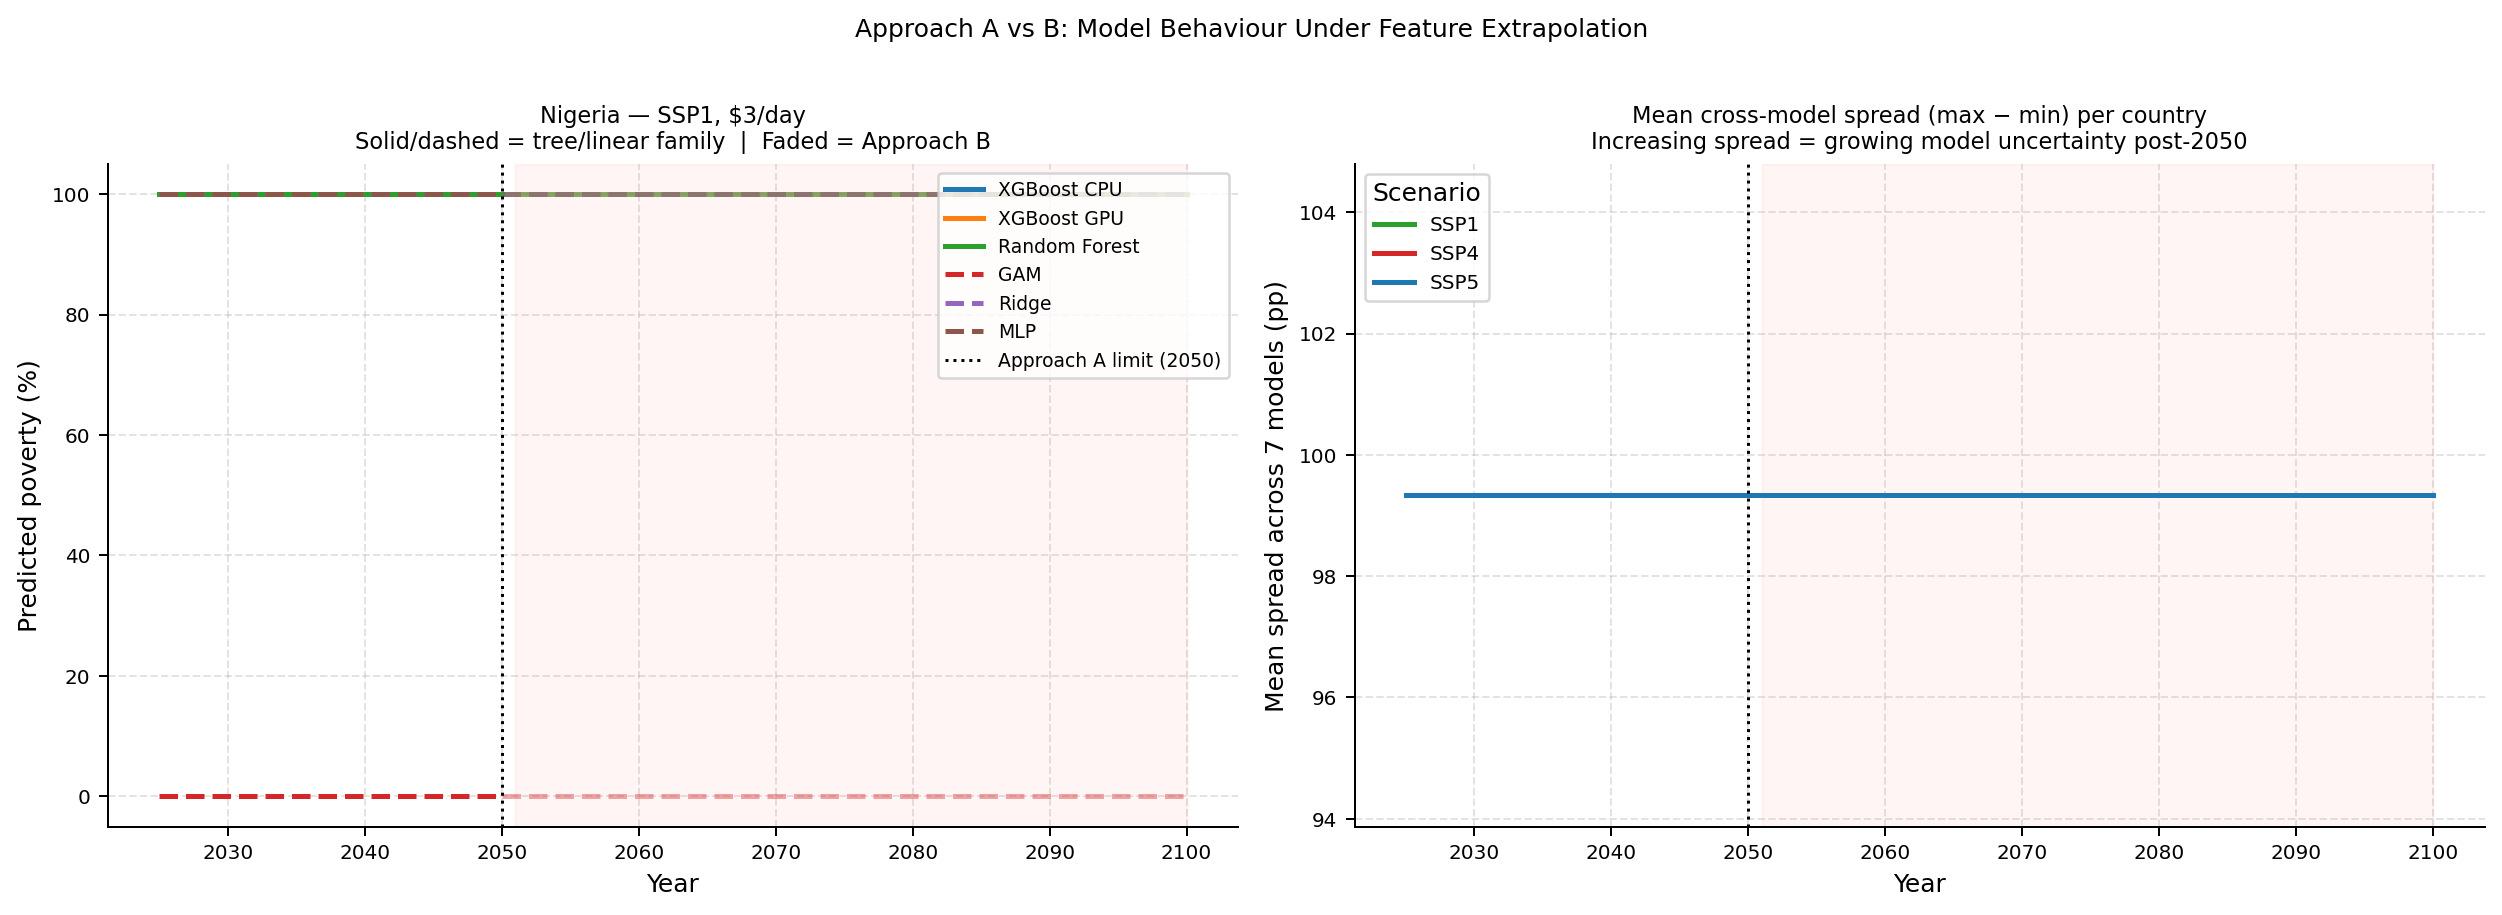

In [9]:
fig5_approach_divergence(OUTPUTS_DIR, threshold="$3", country="Nigeria")
p = REPORT_DIR / "fig5_approach_divergence.png"
if p.exists():
    display(Image(str(p)))

### 5a. Divergence for a second country

  Saved: fig5_approach_divergence.png


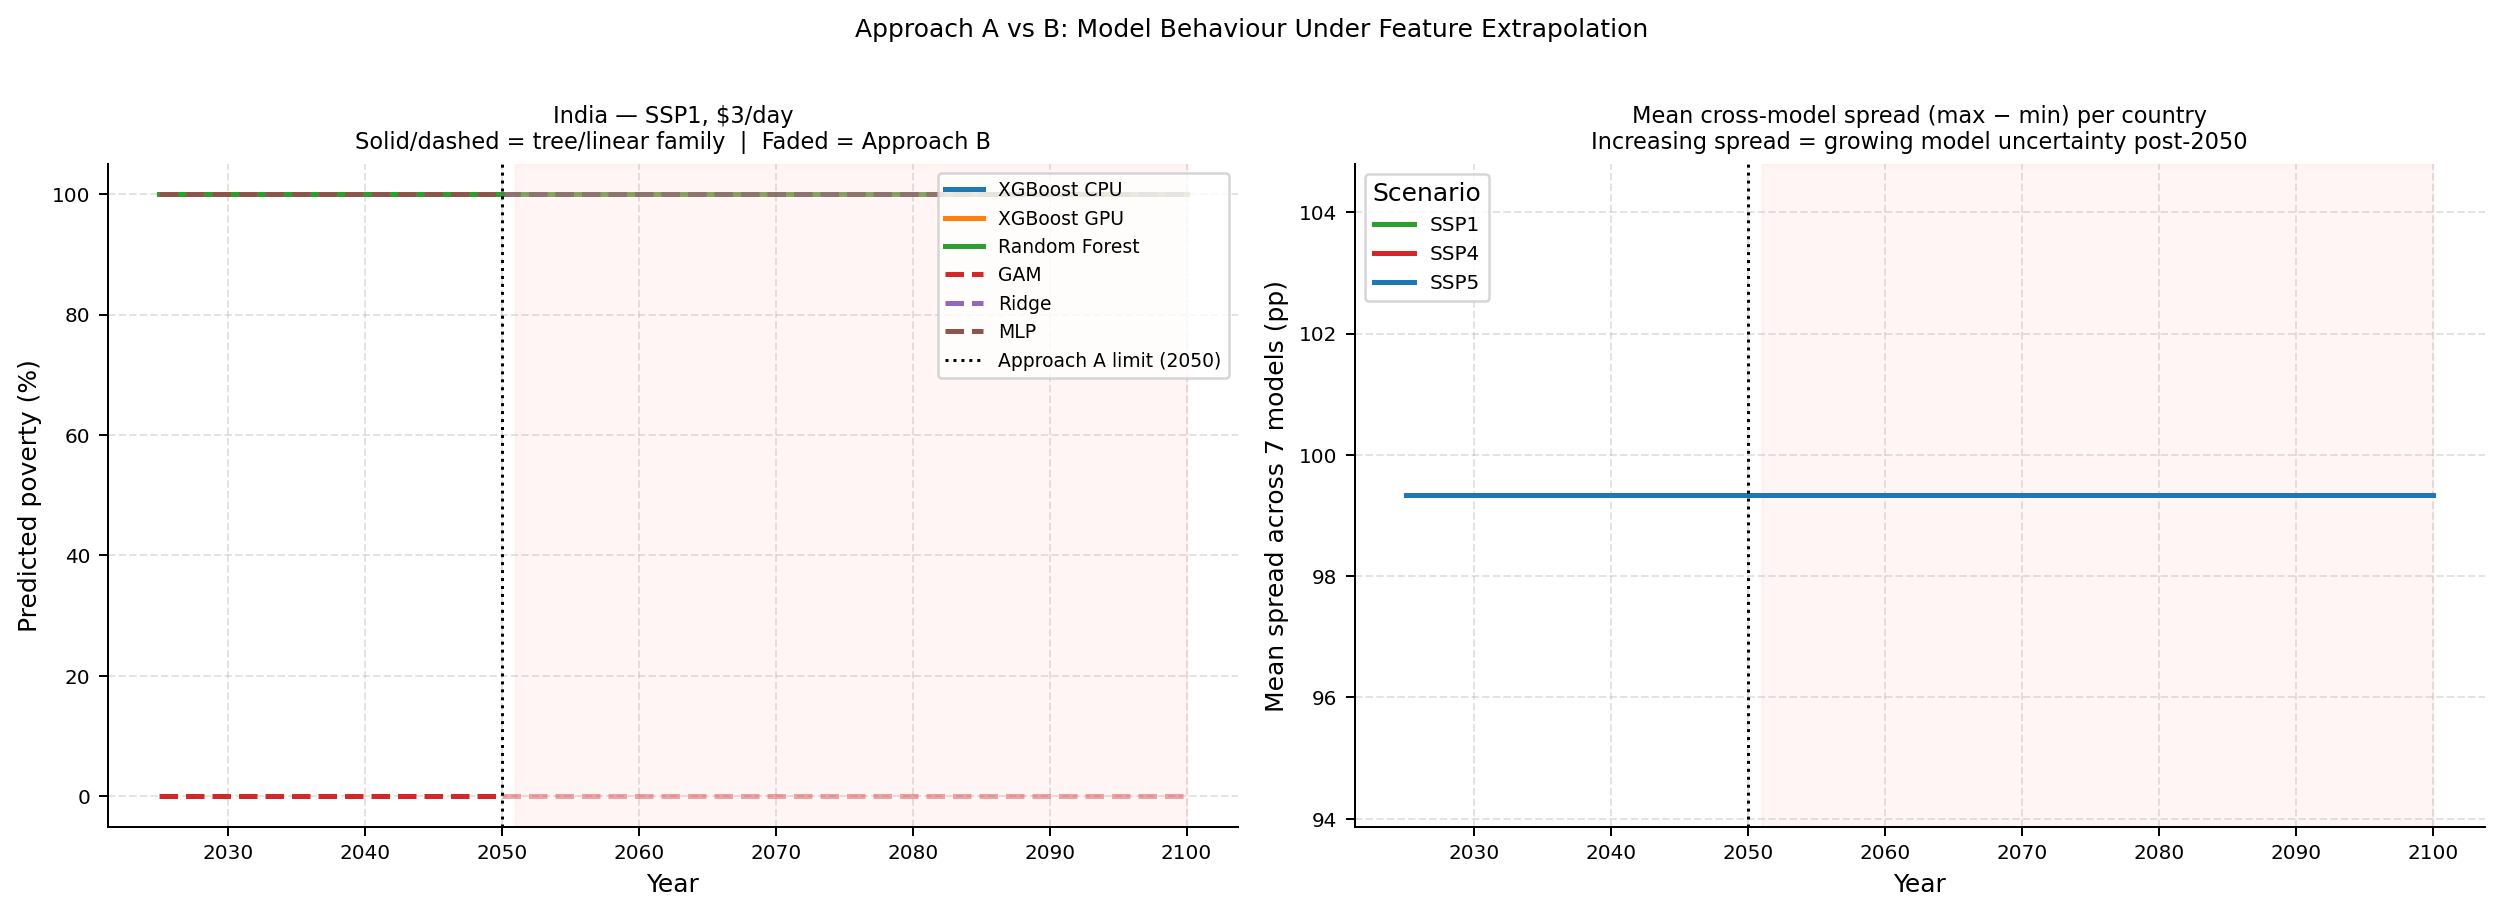

In [10]:
fig5_approach_divergence(OUTPUTS_DIR, threshold="$3", country="India")
p = REPORT_DIR / "fig5_approach_divergence.png"
if p.exists():
    display(Image(str(p)))

## 6. Learning curve (Fig 6)

  Learning curve for: random_forest  params={'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 1}
  Saved: fig6_learning_curve.png


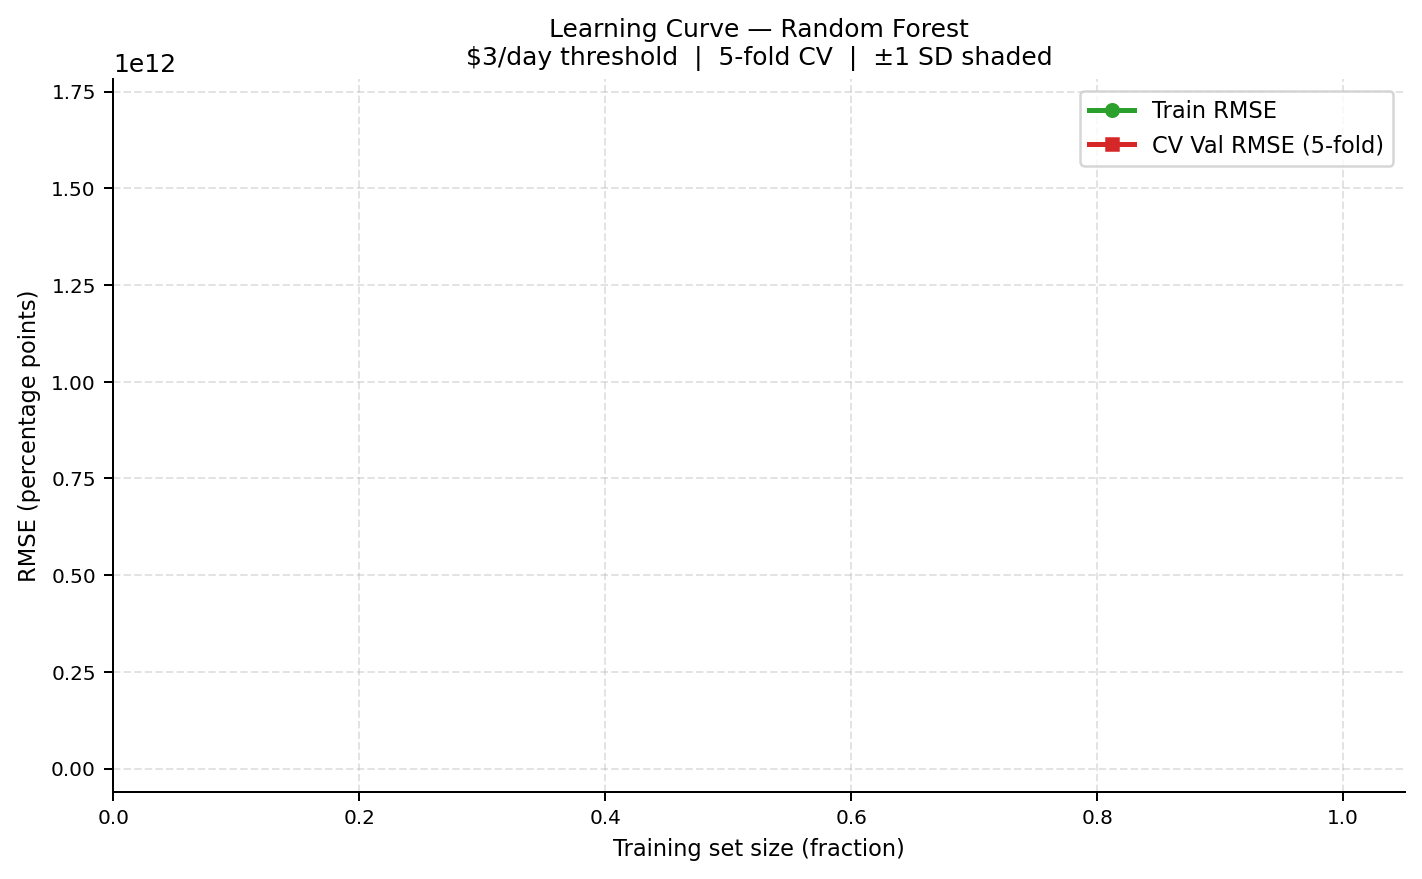

In [11]:
fig6_learning_curve(DATA_FINAL_DIR, OUTPUTS_DIR)
p = REPORT_DIR / "fig6_learning_curve.png"
if p.exists():
    display(Image(str(p)))
else:
    print("Learning curve not generated — check that model pkl exists.")

## 7. Residual analysis (Fig 7)

  Saved: fig7_residual_analysis.png


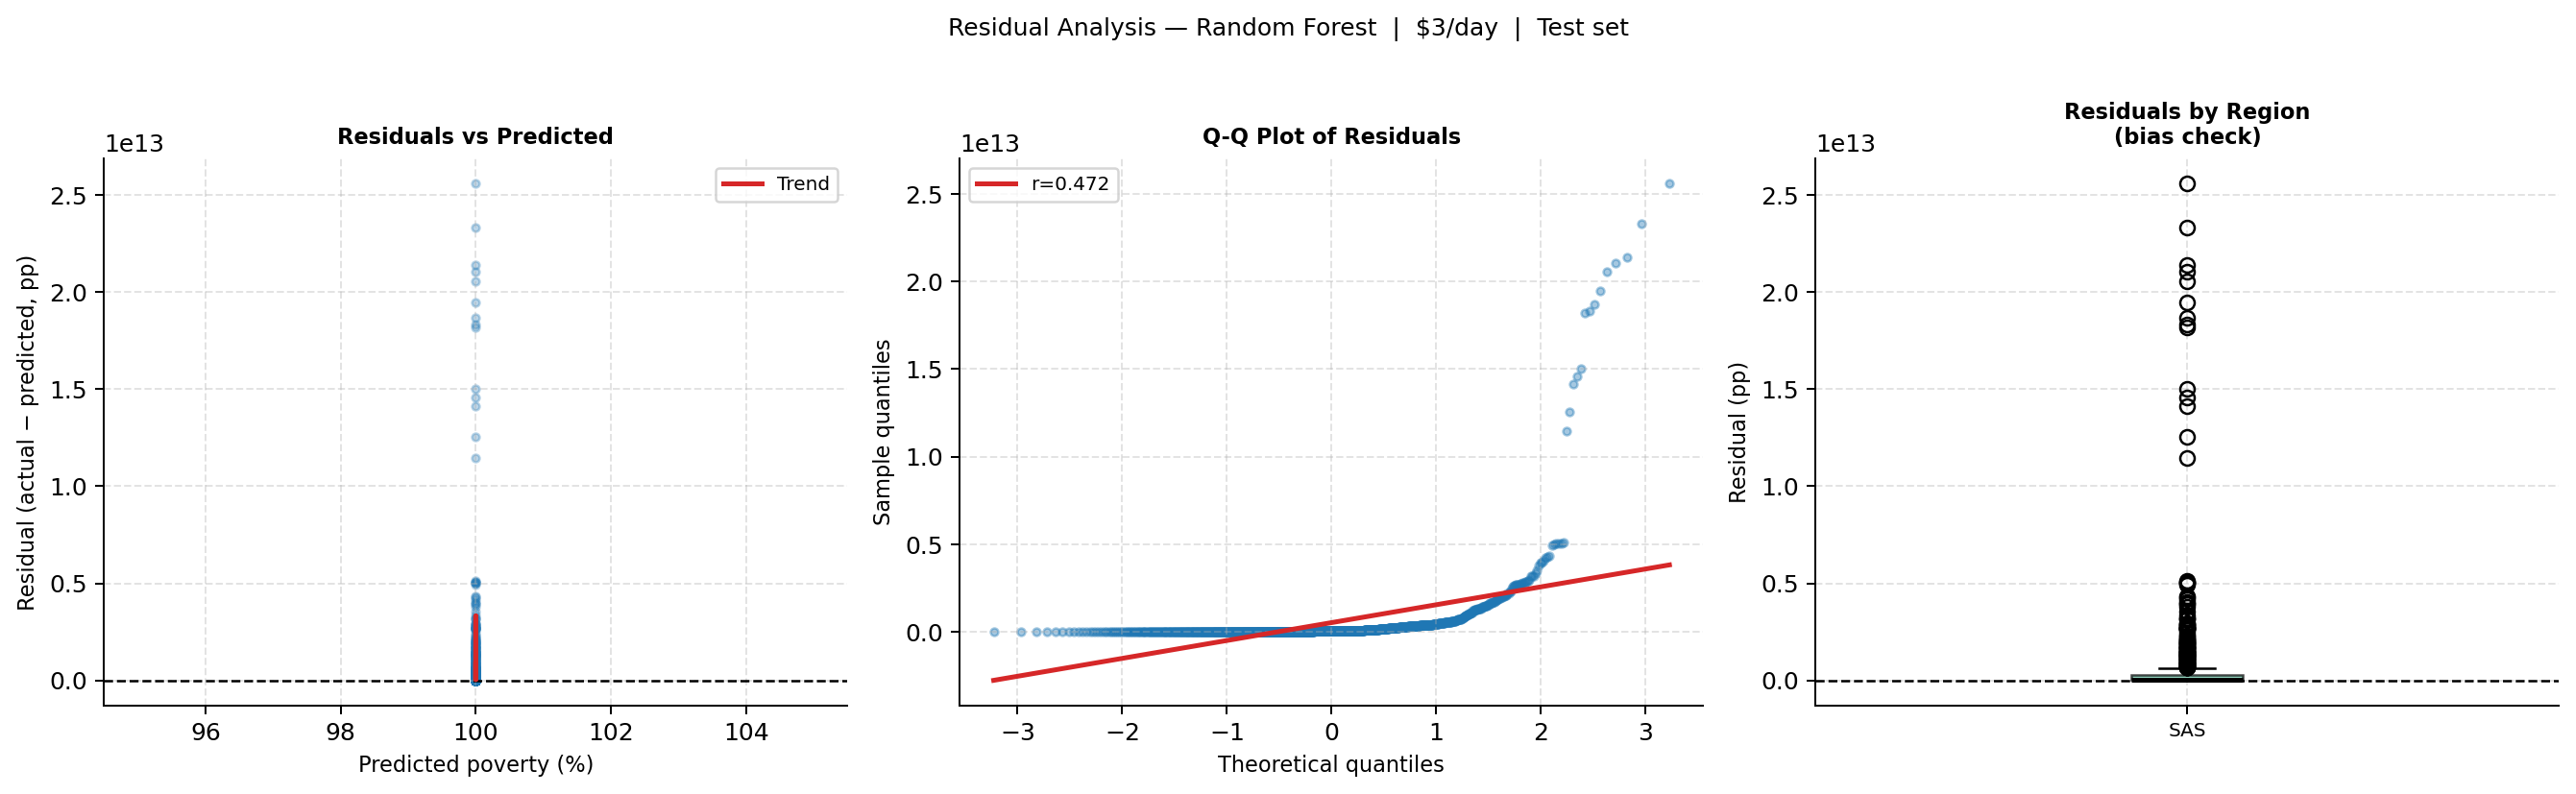

In [12]:
fig7_residual_analysis(DATA_FINAL_DIR, OUTPUTS_DIR)
p = REPORT_DIR / "fig7_residual_analysis.png"
if p.exists():
    display(Image(str(p)))

## 8. Run all figures at once

In [13]:
# Convenience function — runs everything and prints a file listing
results = generate_all_figures(
    final_dir   = DATA_FINAL_DIR,
    outputs_dir = OUTPUTS_DIR,
    countries   = ["Nigeria", "India", "Brazil", "Germany", "United States"],
)

  REPORT FIGURE GENERATION

[1/7] Model performance table…
  Saved: model_performance_primary.csv
  Saved: model_performance_all_thresholds.csv
  Saved: fig1_model_performance.png
  Saved: fig1b_rmse_heatmap_all_thresholds.png

[2/7] Feature importance consensus…
  Saved: fig2_feature_importance_consensus.png

[3/7] Prediction trajectories (per country)…
  Saved: fig3_trajectory_Nigeria.png
  Saved: fig3_trajectory_India.png
  Saved: fig3_trajectory_Brazil.png
  Saved: fig3_trajectory_Germany.png
  Saved: fig3_trajectory_United_States.png

[4/7] Regional trends…
  Saved: fig4_regional_trends.png

[5/7] Approach A vs B divergence…
  Saved: fig5_approach_divergence.png

[6/7] Learning curve…
  Learning curve for: random_forest  params={'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 1}
  Saved: fig6_learning_curve.png

[7/7] Residual analysis…
  Saved: fig7_residual_analysis.png

  Done. 14 files in outputs/report/
    fig1_model_performance.png                                1

## 9. Final report file listing

In [14]:
print("=== Report outputs in outputs/report/ ===")
if REPORT_DIR.exists():
    for p in sorted(REPORT_DIR.rglob("*")):
        print(f"  {p.name:<55}  {p.stat().st_size:>9,} bytes")
else:
    print("Report directory not created yet — run generate_all_figures() first.")

=== Report outputs in outputs/report/ ===
  fig1_model_performance.png                                 101,974 bytes
  fig1b_rmse_heatmap_all_thresholds.png                       91,232 bytes
  fig2_feature_importance_consensus.png                      126,549 bytes
  fig3_trajectory_Brazil.png                                 168,754 bytes
  fig3_trajectory_Germany.png                                153,653 bytes
  fig3_trajectory_India.png                                  171,081 bytes
  fig3_trajectory_Nigeria.png                                175,240 bytes
  fig3_trajectory_United_States.png                          163,863 bytes
  fig4_regional_trends.png                                   141,777 bytes
  fig5_approach_divergence.png                               126,914 bytes
  fig6_learning_curve.png                                     55,496 bytes
  fig7_residual_analysis.png                                 120,025 bytes
  model_performance_all_thresholds.csv                    

## 10. Figure descriptions for the report

### Fig 1 — Model Performance
Primary comparison table and bar chart: RMSE, MAE, R², MAPE on the $3/day
hold-out test set (2016–2022). The supplementary heatmap extends this to all
4 poverty thresholds. Use to argue which model is selected as the "best" and why.

### Fig 2 — Feature Importance Consensus
Grouped bar chart showing mean |SHAP| per feature across all 7 models.
Features sorted by cross-model mean importance. Use to show that GDP per capita
and Gini consistently dominate regardless of model family — lending robustness
to the findings.

### Fig 3 — Country Trajectories
Country-level poverty trajectories under SSP1/4/5. Nigeria and Ethiopia show
diverging scenarios (SSP1 much lower poverty than SSP4/5). Germany and USA show
very low poverty across all scenarios — confirming sanity of predictions.

### Fig 4 — Regional Trends
Aggregates predictions by World Bank region. Sub-Saharan Africa shows the
highest absolute poverty levels; South Asia shows rapid reduction particularly
under SSP1. Use to discuss geographic concentration of poverty risk.

### Fig 5 — Approach A vs B
Shows tree models producing flat predictions after 2050 (plateauing once features
exit the training distribution), while Ridge/MLP continue to extrapolate.
Increasing cross-model spread is used as a proxy for forecast uncertainty.

### Fig 6 — Learning Curve
Diagnoses the bias-variance tradeoff: does the model benefit from more training
data? A converging train/val gap suggests adequate sample size; a persistent gap
suggests the model could benefit from more data or regularisation.

### Fig 7 — Residual Analysis
Checks whether residuals are well-behaved. The regional boxplot reveals any
systematic geographic bias (e.g. consistently over-predicting poverty in one
region). The Q-Q plot checks normality of errors — important for uncertainty
quantification.
